# Guía simbólica completa: Lagrangiano, linealización y matrices normales

Este notebook presenta varios ejemplos resueltos de forma **simbólica y paso a paso**, con el flujo:

1. Definir coordenadas generalizadas.
2. Construir energías $T$ y $U$.
3. Formar el lagrangiano $L=T-U$.
4. Aplicar ecuaciones de Euler-Lagrange.
5. Linealizar (si aplica) para pequeñas oscilaciones.
6. Escribir matrices de masa/inercia $\mathbf M$ y rigidez $\mathbf K$.
7. Resolver $\det(\mathbf K-\omega^2\mathbf M)=0$ y hallar modos propios.

In [1]:
import sympy as sp
sp.init_printing(use_unicode=True)

## Ejemplo 1: Oscilador armónico simple (1 GDL)

Sistema: masa $m$ unida a resorte $k$, coordenada $x$.

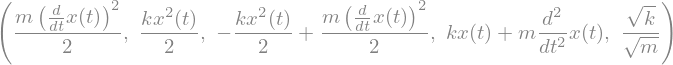

In [2]:
t = sp.symbols('t', real=True)
m, k = sp.symbols('m k', positive=True)
x = sp.Function('x')(t)

# Paso 1: Energías
T1 = sp.Rational(1, 2)*m*sp.diff(x, t)**2
U1 = sp.Rational(1, 2)*k*x**2
L1 = sp.simplify(T1 - U1)

# Paso 2: Euler-Lagrange
EL1 = sp.simplify(sp.diff(sp.diff(L1, sp.diff(x, t)), t) - sp.diff(L1, x))

# Paso 3: Frecuencia natural
omega1 = sp.sqrt(k/m)

T1, U1, L1, EL1, omega1

Resultado: $m\ddot x + kx=0$, con $\omega_0=\sqrt{k/m}$.

Aquí la forma matricial es escalar: $M=[m]$, $K=[k]$, y $\omega^2=K/M$.

## Ejemplo 2: Dos masas acopladas por resortes (2 GDL)

Sistema lineal:
- Masas iguales $m$.
- Resortes laterales $k$ y acoplamiento central $k_c$.
- Coordenadas: $x_1, x_2$.

Energías:
$$
T=\frac12 m(\dot x_1^2+\dot x_2^2),
\quad
U=\frac12 kx_1^2+\frac12 kx_2^2+\frac12 k_c(x_2-x_1)^2.
$$

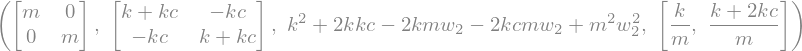

In [3]:
m, k, kc = sp.symbols('m k kc', positive=True)
x1, x2 = sp.symbols('x1 x2', real=True)
dx1, dx2 = sp.symbols('dx1 dx2', real=True)

T2 = sp.Rational(1, 2)*m*(dx1**2 + dx2**2)
U2 = sp.Rational(1, 2)*k*x1**2 + sp.Rational(1, 2)*k*x2**2 + sp.Rational(1, 2)*kc*(x2 - x1)**2

# Matrices por derivadas segundas
q = sp.Matrix([x1, x2])
dq = sp.Matrix([dx1, dx2])

M2 = sp.hessian(T2, (dx1, dx2))
K2 = sp.hessian(U2, (x1, x2))

# Problema generalizado de autovalores
w2 = sp.symbols('w2')
char2 = sp.expand((K2 - w2*M2).det())
w2_vals = sp.solve(sp.Eq(char2, 0), w2)

M2, K2, char2, w2_vals

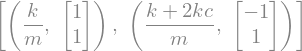

In [4]:
# Autovectores de cada modo (K - w^2 M) v = 0
vects2 = []
for val in w2_vals:
    A = (K2 - val*M2)
    ns = A.nullspace()
    vects2.append((sp.simplify(val), ns[0]))
vects2

Interpretación típica:
- Modo simétrico ($x_1=x_2$): el resorte central no se deforma.
- Modo antisimétrico ($x_1=-x_2$): el acoplamiento central aporta rigidez extra.

## Ejemplo 3: Péndulo doble en aproximación de ángulos pequeños

Parámetros:
- Longitudes $l_1,l_2$, masas puntuales $m_1,m_2$.
- Ángulos pequeños $\theta_1,\theta_2$ respecto a vertical.

Posiciones exactas:
$$
x_1=l_1\sin\theta_1,uad y_1=-l_1\cos\theta_1,
$$
$$
x_2=l_1\sin\theta_1+l_2\sin\theta_2,uad y_2=-l_1\cos\theta_1-l_2\cos\theta_2.
$$
Luego linealizamos con $\sin\theta\approx\theta$, $\cos\theta\approx 1-\theta^2/2$.

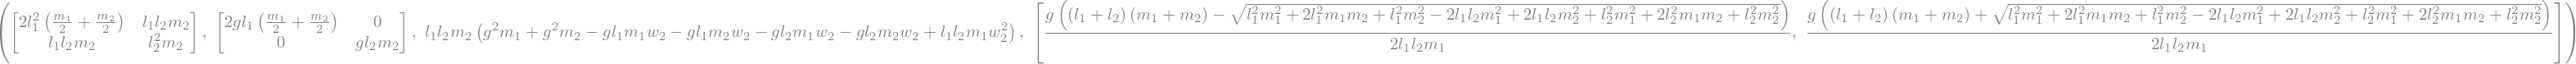

In [5]:
m1, m2, l1, l2, g = sp.symbols('m1 m2 l1 l2 g', positive=True)
th1, th2, dth1, dth2 = sp.symbols('th1 th2 dth1 dth2', real=True)

# Energía cinética linealizada hasta orden cuadrático
T3 = sp.Rational(1, 2)*(m1 + m2)*l1**2*dth1**2 + sp.Rational(1, 2)*m2*l2**2*dth2**2 + m2*l1*l2*dth1*dth2

# Energía potencial linealizada (sin constantes aditivas)
U3 = sp.Rational(1, 2)*(m1 + m2)*g*l1*th1**2 + sp.Rational(1, 2)*m2*g*l2*th2**2

M3 = sp.hessian(T3, (dth1, dth2))
K3 = sp.hessian(U3, (th1, th2))

w2 = sp.symbols('w2')
char3 = sp.factor((K3 - w2*M3).det())
w2_vals3 = sp.solve(sp.Eq(char3, 0), w2)

M3, K3, char3, w2_vals3

Comentarios:
- El término cruzado en $T$ genera acoplamiento inercial.
- El problema modal sale de $\det(K-\omega^2 M)=0$.
- Al fijar valores numéricos, se obtienen dos frecuencias normales y sus modos (en fase / contrafase, según parámetros).

## Ejemplo 4: Anillo suspendido + masa deslizante (tu tipo de problema)

Variables:
- $\theta$: oscilación global del anillo respecto a vertical.
- $\phi$: posición de la masa sobre el anillo.

Alrededor del equilibrio estable $\theta=0$, $\phi=\pi$ definimos $\eta=\phi-\pi$ y se obtiene (a segundo orden):
$$
T = \frac12\dot{\mathbf q}^T M_4 \dot{\mathbf q},
\quad
U = \frac12\mathbf q^T K_4 \mathbf q,
\quad
\mathbf q=\begin{bmatrix}\theta\\\eta\end{bmatrix},
$$
con
$$
M_4=MR^2\begin{bmatrix}6&2\\2&1\end{bmatrix},quad
K_4=MgR\begin{bmatrix}3&1\\1&1\end{bmatrix}.
$$

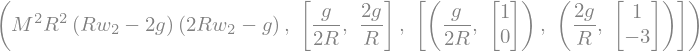

In [6]:
M, R, g = sp.symbols('M R g', positive=True)
w2 = sp.symbols('w2')

M4 = M*R**2*sp.Matrix([[6, 2], [2, 1]])
K4 = M*g*R*sp.Matrix([[3, 1], [1, 1]])

char4 = sp.factor((K4 - w2*M4).det())
w2_vals4 = sp.solve(sp.Eq(char4, 0), w2)

modes4 = []
for val in w2_vals4:
    vec = (K4 - val*M4).nullspace()[0]
    modes4.append((sp.simplify(val), sp.simplify(vec/vec[0])))

char4, w2_vals4, modes4

Se recupera simbólicamente:
$$
\omega_1^2=\frac{2g}{R},\qquad \omega_2^2=\frac{g}{2R},
$$
con formas modales proporcionales a:
$$
v_1\propto\begin{bmatrix}1\\-3\end{bmatrix},quad
v_2\propto\begin{bmatrix}1\\0\end{bmatrix}.
$$

## Ejemplo 5: Tensor de inercia y ejes principales (placa rombo)

Objetivo: mostrar el flujo completo para pasar de integrales geométricas al problema de autovalores de inercia en el plano.

Para rombo de lado $a$ y ángulo $\pi/3$, respecto a un vértice y ejes en los lados, el bloque plano es:
$$
I_{plano}=
\begin{bmatrix}
I_{xx} & I_{xy}\\
I_{xy} & I_{yy}
\end{bmatrix}
=ma^2\begin{bmatrix}
1/4 & -5/(8\sqrt3)\\
-5/(8\sqrt3) & 2/3
\end{bmatrix}.
$$
Los ejes principales se hallan diagonalizando esta matriz.

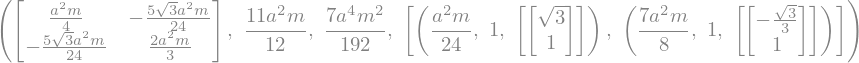

In [7]:
m, a = sp.symbols('m a', positive=True)
Iplane = m*a**2*sp.Matrix([[sp.Rational(1,4), -sp.Rational(5,8)/sp.sqrt(3)],
                          [-sp.Rational(5,8)/sp.sqrt(3), sp.Rational(2,3)]])

eigs5 = Iplane.eigenvects()
trace5 = sp.simplify(Iplane.trace())
det5 = sp.simplify(Iplane.det())

Iplane, trace5, det5, eigs5

Resultados principales:
- Momentos principales en el plano: $I_1=\frac{7}{8}ma^2$, $I_2=\frac{1}{24}ma^2$.
- El ángulo de rotación de ejes cumple $\tan(2\alpha)=\sqrt3\Rightarrow\alpha=\pi/6$.

Este patrón (construir matriz simétrica y diagonalizar) es exactamente el mismo que en oscilaciones pequeñas con $K-\omega^2M$; cambia la interpretación física, pero el álgebra lineal es análoga.

## Plantilla general para cualquier problema nuevo

1. Elegir $q_i$ mínimos e independientes.
2. Escribir $T(q,\dot q)$ y $U(q)$ exactos.
3. Hallar equilibrio $q=q_0$.
4. Definir perturbaciones $\eta=q-q_0$.
5. Expandir hasta segundo orden:
   - $T\approx\frac12\dot\eta^T M \dot\eta$.
   - $U\approx\frac12\eta^T K \eta$.
6. Resolver $\det(K-\omega^2M)=0$.
7. Para cada $\omega_n^2$, obtener $v_n$ de $(K-\omega_n^2M)v_n=0$.
8. Escribir solución general como superposición modal.